In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Create 4x4 array with random integers between 10 and 100
arr = np.random.randint(10, 101, size=(4, 4))
print("Original Array:\n", arr)

# Replace even numbers with their square roots
# Replace odd numbers with -1
modified_arr = np.where(arr % 2 == 0, np.sqrt(arr), -1)

print("\nModified Array:\n", modified_arr)

Original Array:
 [[43 29 69 71]
 [73 50 13 82]
 [80 60 80 95]
 [39 30 85 39]]

Modified Array:
 [[-1.         -1.         -1.         -1.        ]
 [-1.          7.07106781 -1.          9.05538514]
 [ 8.94427191  7.74596669  8.94427191 -1.        ]
 [-1.          5.47722558 -1.         -1.        ]]


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/ultimate_student_productivity_dataset_5000.csv")

# Display top 10 rows
print(df.head(10))

# Dataset info
print(df.info())

# Summary statistics
print(df.describe())

   student_id  age  gender academic_level  study_hours  self_study_hours  \
0           1   18   Other    High School         7.64              1.56   
1           2   18   Other    High School         2.21              2.22   
2           3   22    Male    High School         3.45              0.00   
3           4   17   Other    High School         5.75              2.08   
4           5   19   Other    High School         6.83              1.72   
5           6   25    Male  Undergraduate         2.21              3.50   
6           7   22   Other    High School         4.60              2.37   
7           8   17    Male    High School         8.77              3.78   
8           9   16  Female  Undergraduate         6.60              0.84   
9          10   17  Female    High School         3.98              0.16   

   online_classes_hours  social_media_hours  gaming_hours  sleep_hours  ...  \
0                  2.20                3.05          2.19         6.52  ...   
1    

In [ ]:
# Missing values
print(df.isnull().sum())

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64


In [ ]:
# Fill numeric columns with median
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
if 'age' in df.columns:
    print("Mean Age:", df['age'].mean())

Mean Age: 20.5204


In [ ]:
if 'sleep_hours' in df.columns:
    print("Average Study Hours:", df['sleep_hours'].mean())

Average Study Hours: 7.0164919999999995


In [ ]:
df.columns = df.columns.str.strip()

print("Columns:", df.columns)

result = df.groupby('gender')['productivity_score'].mean()

print("Result:")
print(result)

Columns: Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='object')
Result:
gender
Female    37.384601
Male      37.546038
Other     36.862532
Name: productivity_score, dtype: float64


In [ ]:
corr = df.select_dtypes(include='number').corr()
print(corr)

                      student_id       age  study_hours  self_study_hours  \
student_id              1.000000  0.015223    -0.018550         -0.020115   
age                     0.015223  1.000000     0.000511          0.004889   
study_hours            -0.018550  0.000511     1.000000         -0.003942   
self_study_hours       -0.020115  0.004889    -0.003942          1.000000   
online_classes_hours   -0.003989 -0.001553     0.011238         -0.010100   
social_media_hours      0.019322  0.004207    -0.000296         -0.015582   
gaming_hours            0.007484  0.013768     0.017475          0.000569   
sleep_hours            -0.017050  0.004719    -0.027995         -0.007138   
screen_time_hours      -0.003596  0.001662    -0.022899         -0.016264   
exercise_minutes       -0.003271  0.016355    -0.004847          0.006304   
caffeine_intake_mg      0.031160  0.000437    -0.015362          0.007317   
part_time_job           0.009575 -0.015375    -0.017781          0.017677   

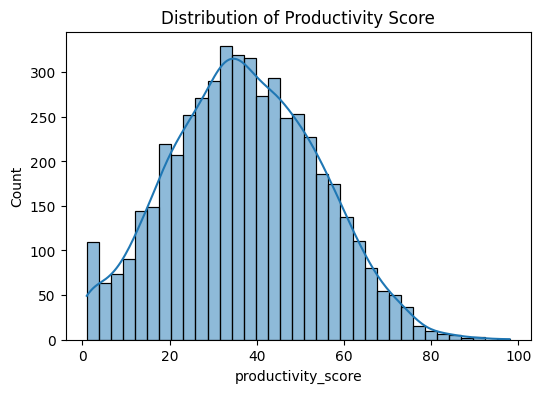

In [ ]:
if 'productivity_score' in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df['productivity_score'], kde=True)
    plt.title("Distribution of Productivity Score")
    plt.show()

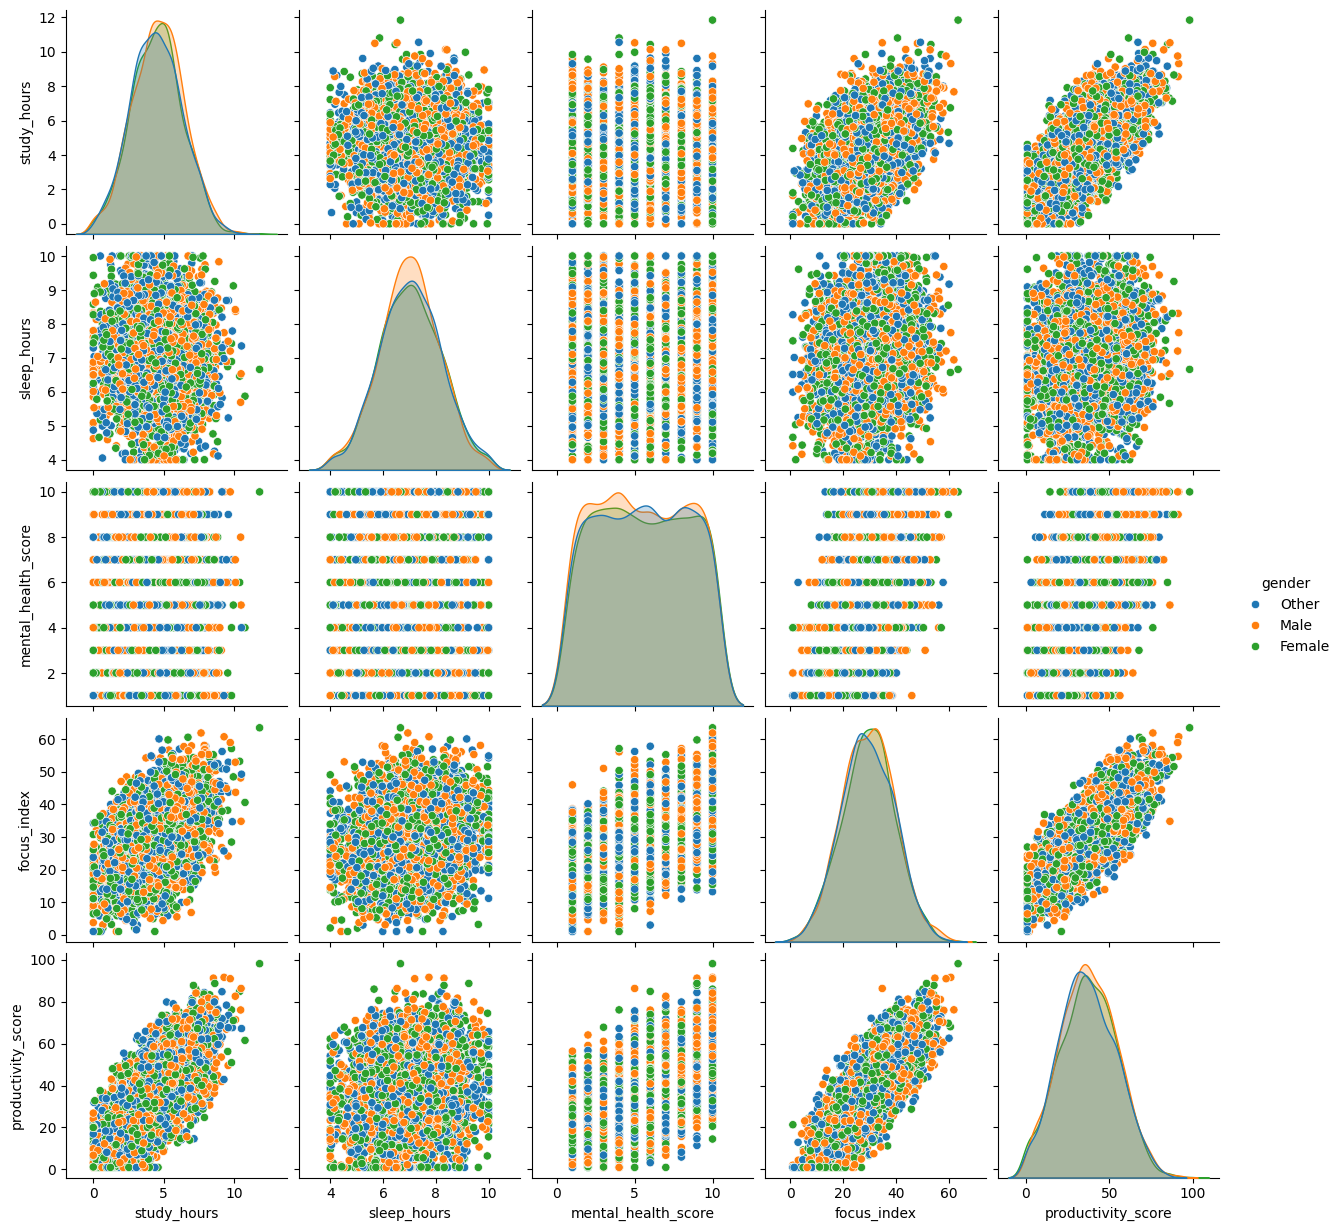

In [ ]:
#Pairplot
selected_cols = [
    'study_hours',
    'sleep_hours',
    'mental_health_score',
    'focus_index',
    'productivity_score'
]

sns.pairplot(
    df[selected_cols + ['gender']],
    hue='gender',
    diag_kind='kde'
)

plt.show()

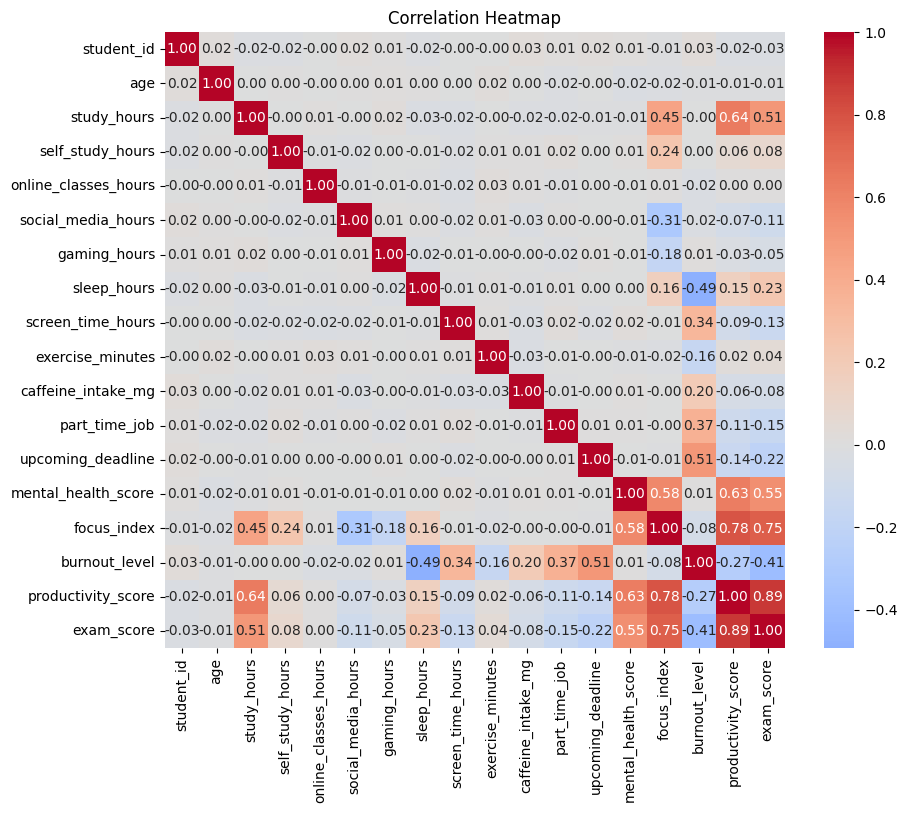

In [ ]:
#Heatmap
plt.figure(figsize=(10, 8))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

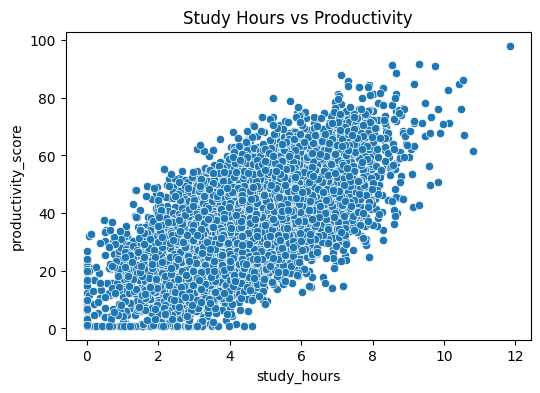

In [ ]:
#Scatter plot
if 'study_hours' in df.columns and 'productivity_score' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x='study_hours', y='productivity_score')
    plt.title("Study Hours vs Productivity")
    plt.show()

In [ ]:
#strong corrilation
strong_corr = corr[(corr > 0.6) | (corr < -0.6)]
print("Strong Correlations:\n")
print(strong_corr.dropna(how='all').dropna(axis=1, how='all'))

Strong Correlations:

                      student_id  age  study_hours  self_study_hours  \
student_id                   1.0  NaN          NaN               NaN   
age                          NaN  1.0          NaN               NaN   
study_hours                  NaN  NaN     1.000000               NaN   
self_study_hours             NaN  NaN          NaN               1.0   
online_classes_hours         NaN  NaN          NaN               NaN   
social_media_hours           NaN  NaN          NaN               NaN   
gaming_hours                 NaN  NaN          NaN               NaN   
sleep_hours                  NaN  NaN          NaN               NaN   
screen_time_hours            NaN  NaN          NaN               NaN   
exercise_minutes             NaN  NaN          NaN               NaN   
caffeine_intake_mg           NaN  NaN          NaN               NaN   
part_time_job                NaN  NaN          NaN               NaN   
upcoming_deadline            NaN  NaN     

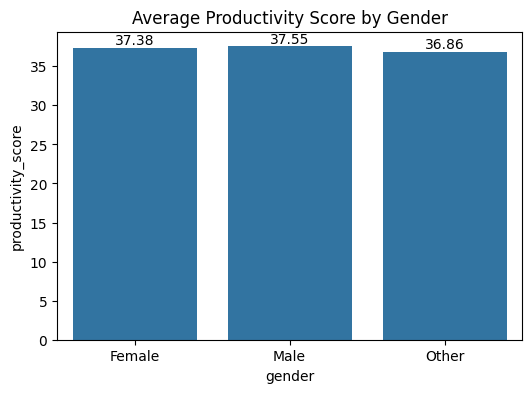

In [ ]:
#Bar Plot
avg_prod = df.groupby('gender')['productivity_score'].mean().reset_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=avg_prod, x='gender', y='productivity_score')

plt.title("Average Productivity Score by Gender")

# Annotate values
for i, row in avg_prod.iterrows():
    ax.text(i, row['productivity_score'],
            round(row['productivity_score'], 2),
            ha='center', va='bottom')

plt.show()

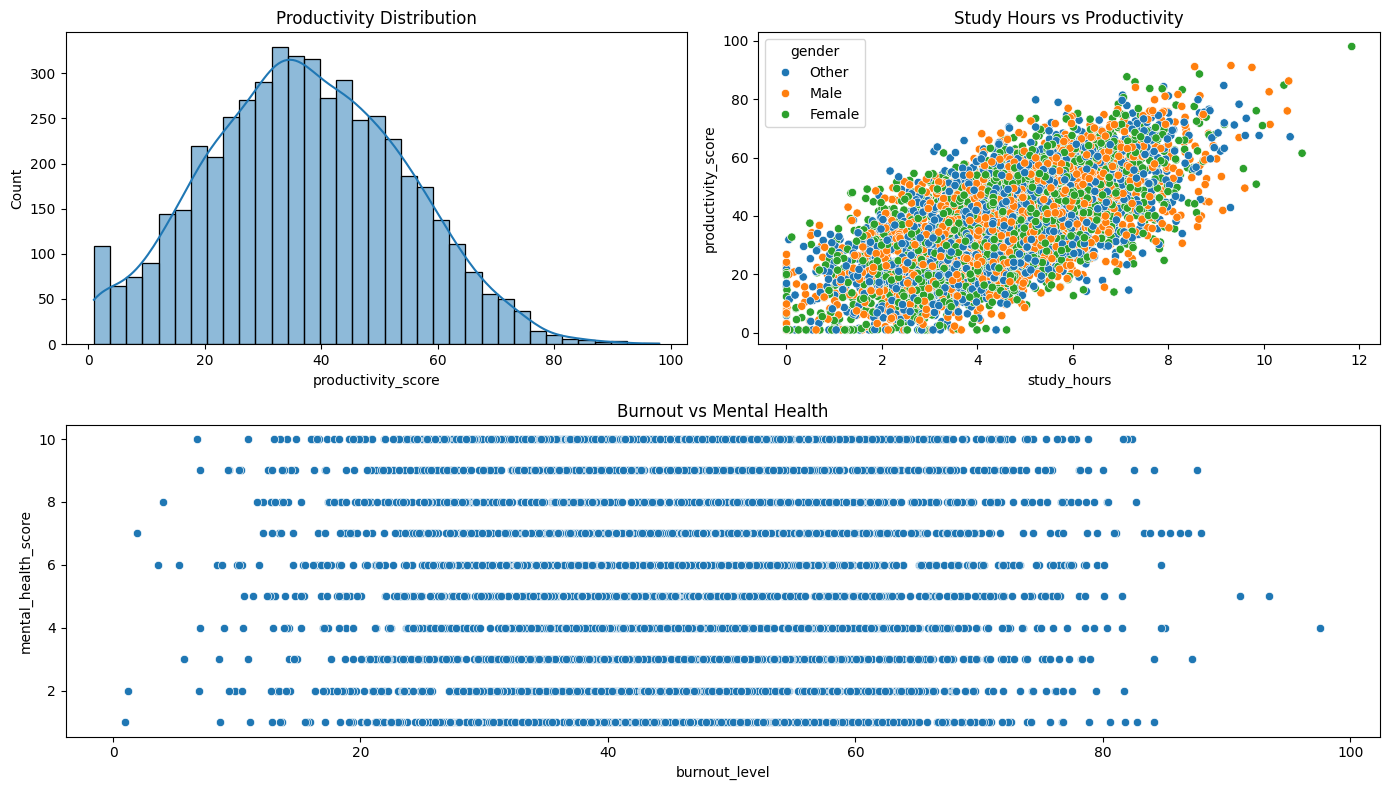

In [ ]:
#Dashboard style
plt.figure(figsize=(14, 8))

# 1️⃣ Productivity Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['productivity_score'], kde=True)
plt.title("Productivity Distribution")

# 2️⃣ Study Hours vs Productivity
plt.subplot(2, 2, 2)
sns.scatterplot(
    data=df,
    x='study_hours',
    y='productivity_score',
    hue='gender'
)
plt.title("Study Hours vs Productivity")

# 3️⃣ Burnout vs Mental Health
plt.subplot(2, 1, 2)
sns.scatterplot(
    data=df,
    x='burnout_level',
    y='mental_health_score'
)
plt.title("Burnout vs Mental Health")

plt.tight_layout()
plt.show()